In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon

In [3]:
import numpy as np
from scipy.sparse import issparse

In [4]:
# from mac_call import annotate_macrophage_polarization
import importlib
import mac_call
importlib.reload(mac_call)

<module 'mac_call' from '/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/code/Clustering/R01_Submission/spp1_Macrophage_Analysis/mac_call.py'>

In [5]:
# Info
whatFer = "one" # "one" or  "two"

#Load data
#So .X is log1p(CP1e6) (CPM-style per-million normalization, then log1p)
base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
adata_file = base_folder / f"{whatFer}fer.h5ad"
# out_figs = base_folder / "figures"
# out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/")

adata = sc.read_h5ad(adata_file)
# ST_sample = sc.read_h5ad(adata_file)

In [38]:
adata.obs['tumor_loc'] = (
    adata.obs['mouse'].str.split('_', n=2).str[1].astype('Int64')  # nullable int
)

In [6]:
# # Load nuclei polygons
# segmentation_path = Path("/mnt/c/Users/jonan/Documents/1Work/Roselab/Spatial/CAR_T/data/cell_segmentation/")
# gdf_file = segmentation_path / "concatenated" / "combined_nuclei_geometry.gpkg"
# gdf = gpd.read_file(gdf_file)


ERROR 1: PROJ: proj_create_from_database: Open of /home/jon/anaconda3/envs/spatial_analysis_env/share/proj failed


## Library selection

In [7]:
# sample_name = "RTCyPSCA_1_4"
# lib_id = "F07839"
# # lib_id = "F07840"
# lib = lib_id
# adata = ST_sample[ST_sample.obs['mouse']==sample_name].copy()

# Annotating Macrophages

In [9]:
# Assuming you already defined:
# sample_name = "RTCyPSCA_1_4"
# lib_id = "F07839"
# adata = ST_sample[ST_sample.obs['mouse']==sample_name].copy()

mac_call.annotate_macrophage_polarization(
    adata,
    counts_layer="counts",   # falls back to .X if 'counts' layer missing
    detect_threshold=1,      # ≥1 UMI per-gene; set to 2 to be stricter
    m1_total_req=3, m1_core_req=2,
    m2_total_req=4, m2_core_req=3,
    tie_margin=0.02,
    write_prefix="",         # e.g., use "RT_" if you want namespaced columns
    verbose=True
)

# quick peek
cols = [
    "Mac_polarization_tiered","Mac_like_tiered",
    "Spp1_pos","Glp1r_pos","Mac_Spp1_pos","Mac_Glp1r_pos","Mac_marker_combo",
    "M1_total","M2_total","M1_score_tiered","M2_score_tiered"
]
cols = [c for c in cols if c in adata.obs.columns]
adata.obs[cols].head(20)


Mac polarization added. N cells = 169773
Class counts: {'Neither': 149597, 'M1': 15123, 'M2': 4976, 'Both': 77}
Spp1+ (≥1 UMI): 100062 | Glp1r+ (≥1 UMI): 2383
Mac marker combos: {'Non-mac': 149597, 'Spp1': 15258, 'None': 4607, 'Both': 295, 'Glp1r': 16}


,Mac_polarization_tiered,Mac_like_tiered,Spp1_pos,Glp1r_pos,Mac_Spp1_pos,Mac_Glp1r_pos,Mac_marker_combo,M1_total,M2_total,M1_score_tiered,M2_score_tiered
ID_100000,Neither,0,1,0,0,0,Non-mac,1,4,0.05,0.181818
ID_100001,Neither,0,0,0,0,0,Non-mac,0,1,0.00,0.045455
ID_100005,Neither,0,0,0,0,0,Non-mac,1,4,0.05,0.181818
ID_100006,Neither,0,0,0,0,0,Non-mac,0,1,0.00,0.045455
ID_100007,Neither,0,1,0,0,0,Non-mac,0,1,0.00,0.045455
ID_100008,Neither,0,0,0,0,0,Non-mac,0,1,0.00,0.045455
ID_100009,Neither,0,1,0,0,0,Non-mac,1,2,0.05,0.090909
ID_10001,Neither,0,0,0,0,0,Non-mac,1,3,0.05,0.136364
ID_100010,Neither,0,0,0,0,0,Non-mac,0,3,0.00,0.136364
ID_100011,Neither,0,1,0,0,0,Non-mac,0,3,0.00,0.136364


# DE Analysis

## Spp1

In [48]:
# --- Per-mouse per-cell DE (Spp1+ vs Spp1-) inside macrophages + KEGG preranked GSEA ---
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import gseapy as gp
import matplotlib.pyplot as plt

# --------- CONFIG ----------
out_loc = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/")
out_loc.mkdir(parents=True, exist_ok=True)

prefix = ""                 # set to your write_prefix if you used one earlier
mac_col  = f"{prefix}Mac_like_tiered"   # 1/0
spp1_col = f"{prefix}Spp1_pos"          # 1/0
mouse_key = "mouse"                      # change to "sample" if that's your subject ID
min_cells_per_grp = 100                  # >=100 Spp1+ and >=100 Spp1- macs per mouse
# --------------------------------------

# quick sanity
assert mac_col in adata.obs.columns and spp1_col in adata.obs.columns and mouse_key in adata.obs.columns

# restrict to macrophages
mac_mask = adata.obs[mac_col].astype(bool).values
adata_mac = adata[mac_mask].copy()

# group labels inside macs
adata_mac.obs["spp1_grp"] = np.where(adata_mac.obs[spp1_col].astype(int).values == 1, "Spp1pos", "Spp1neg")

# per-mouse counts
ct = (adata_mac.obs.groupby([mouse_key, "spp1_grp"]).size().unstack(fill_value=0))
eligible_mice = ct.index[(ct.get("Spp1pos", 0) >= min_cells_per_grp) & (ct.get("Spp1neg", 0) >= min_cells_per_grp)].tolist()

print(f"Eligible mice (>= {min_cells_per_grp} Spp1+ and >= {min_cells_per_grp} Spp1- macs): {len(eligible_mice)}")
if len(eligible_mice) == 0:
    raise ValueError("No mice meet the cell-count threshold. Lower min_cells_per_grp or aggregate differently.")

# helper: extract rank_genes_groups to DataFrame
def rgg_to_df(adata_rgg, group="Spp1pos"):
    rg = adata_rgg.uns["rank_genes_groups"]
    # Scanpy stores arrays per field keyed by 'names','pvals','pvals_adj','logfoldchanges','scores'
    cols = ["names", "pvals", "pvals_adj", "logfoldchanges", "scores"]
    d = {c: pd.Series(rg[c][group], dtype=object) for c in cols}
    df = pd.DataFrame(d)
    df = df.rename(columns={"names": "gene", "logfoldchanges": "log2FC", "pvals_adj": "padj", "pvals": "pval", "scores": "score"})
    # enforce numeric
    for c in ["log2FC","padj","pval","score"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.set_index("gene")

# iterate per mouse
summary_rows = []
for m in eligible_mice:
    print(f"\nMouse {m}: DE (Spp1+ vs Spp1-) within macrophages")
    sub = adata_mac[adata_mac.obs[mouse_key] == m].copy()

    # DE per cell: Wilcoxon, group 'Spp1pos' vs reference 'Spp1neg'
    sc.tl.rank_genes_groups(sub, groupby="spp1_grp", groups=["Spp1pos"], reference="Spp1neg",
                            method="wilcoxon", pts=True, tie_correct=True)

    # Collect DE results
    de = rgg_to_df(sub, group="Spp1pos")
    # Rank score that uses both effect size and significance (signed, larger = stronger up in Spp1+)
    # You can tune this; product of lfc and -log10(pval) is common:
    de["rank_score"] = de["log2FC"] * (-np.log10(de["pval"].clip(lower=1e-300)))
    de = de.sort_values("rank_score", ascending=False)

    # Save per-mouse DE
    de_path = out_loc / f"mouse_{m}_DE_spp1pos_vs_spp1neg.csv"
    de.to_csv(de_path)

    # ---- GSEA: preranked KEGG mouse ----
    from numpy.random import RandomState

    def _col(df, *cands):
        """Return the first matching column (case-insensitive); raises if none found."""
        low = {c.lower(): c for c in df.columns}
        for c in cands:
            if c in df.columns: 
                return c
            if c.lower() in low:
                return low[c.lower()]
        raise KeyError(f"None of columns found: {cands} in {list(df.columns)}")
    
    # Build (gene, score) table and add tiny jitter to break ties
    rnk = de[["rank_score"]].rename(columns={"rank_score": "score"}).reset_index().rename(columns={"index":"gene"})
    if rnk["score"].duplicated().mean() > 0:
        rng = RandomState(0)
        rnk["score"] = rnk["score"].values + 1e-9 * rng.randn(len(rnk))
    
    pr = gp.prerank(
        rnk=rnk,
        gene_sets="KEGG_2019_Mouse",
        min_size=10, max_size=500,
        threads=4,  # 'processes' is deprecated
        seed=0, verbose=False
    )
    
    enr = pr.res2d.copy()
    # Standardize expected columns
    NES = _col(enr, "NES")
    FDR = _col(enr, "FDR q-val", "FDR", "fdr", "fdr_q_val")
    TERM = _col(enr, "Term", "term", "Gene_set", "Name")
    
    # Sort by FDR, then by |NES|
    enr = enr.sort_values([FDR, NES], ascending=[True, False])
    enr_path = out_loc / f"mouse_{m}_KEGG_prerank.csv"
    enr.to_csv(enr_path, index=False)
    
    # Select top-10 up/down by FDR with NES sign
    enr_up   = enr[enr[NES] > 0].head(10)
    enr_down = enr[enr[NES] < 0].head(10)
    
    # Plot Top-10 Up
    plt.figure(figsize=(8, 5))
    y = list(enr_up[TERM])[::-1]
    x = enr_up.loc[enr_up.index[::-1], NES].values
    plt.barh(y, x)
    plt.xlabel("NES (up in Spp1+)")
    plt.title(f"Mouse {m} — KEGG prerank: Top 10 Up (Spp1+)")
    plt.tight_layout()
    plt.savefig(out_loc / f"mouse_{m}_KEGG_top10_up.png", dpi=300)
    plt.close()
    
    # Plot Top-10 Down
    plt.figure(figsize=(8, 5))
    y = list(enr_down[TERM])[::-1]
    x = enr_down.loc[enr_down.index[::-1], NES].values
    plt.barh(y, x)
    plt.xlabel("NES (down in Spp1+)")
    plt.title(f"Mouse {m} — KEGG prerank: Top 10 Down (Spp1+)")
    plt.tight_layout()
    plt.savefig(out_loc / f"mouse_{m}_KEGG_top10_down.png", dpi=300)
    plt.close()

# write a manifest
manifest = pd.DataFrame(summary_rows)
manifest.to_csv(out_loc / "manifest_per_mouse_DE_GSEA.csv", index=False)
print("\nDone. Wrote per-mouse DE and KEGG GSEA plus plots. See manifest for file paths.")


Eligible mice (>= 100 Spp1+ and >= 100 Spp1- macs): 7

Mouse CyPSCA_1_1: DE (Spp1+ vs Spp1-) within macrophages


... storing 'spp1_grp' as categorical
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide



Mouse CyPSCA_1_2: DE (Spp1+ vs Spp1-) within macrophages


... storing 'spp1_grp' as categorical
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide



Mouse CyT72_1_4: DE (Spp1+ vs Spp1-) within macrophages


...


Mouse RTCyT72_2_1: DE (Spp1+ vs Spp1-) within macrophages


... storing 'spp1_grp' as categorical
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide



Mouse RTCyT72_2_4: DE (Spp1+ vs Spp1-) within macrophages


... storing 'spp1_grp' as categorical
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide



Done. Wrote per-mouse DE and KEGG GSEA plus plots. See manifest for file paths.


In [47]:
pr.res2d.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Graft-versus-host disease,-0.734764,-2.015401,0.0,0.0,0.0,4/37,1.63%,H2-Ab1;H2-Eb1;H2-Aa;H2-M2
1,prerank,Apelin signaling pathway,0.958035,1.942273,0.004012,0.351198,0.157,4/128,0.44%,Spp1;Hras;Ccnd1;Akt1
2,prerank,Toll-like receptor signaling pathway,0.966782,1.931259,0.006054,0.307059,0.215,1/91,0.01%,Spp1
3,prerank,ECM-receptor interaction,0.958269,1.90347,0.005035,0.330088,0.29,9/79,0.92%,Spp1;Fn1;Itga6;Ibsp;Cd44;Col6a3;Sdc1;Col4a1;Itgb7
4,prerank,Focal adhesion,0.920967,1.892372,0.007,0.261959,0.304,13/188,1.20%,Spp1;Fn1;Hras;Itga6;Rap1b;Ccnd1;Ibsp;Akt1;Col6...


# Introducing LIANA results

In [49]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
from anndata import AnnData
from collections import defaultdict

assert 'mouse' in adata.obs.columns, "Expected adata.obs['mouse']"
mice = adata.obs['mouse'].astype(str).unique().tolist()

print(f"Found {len(mice)} mice: {mice[:6]}{' ...' if len(mice) > 6 else ''}")
print(f"N cells total: {adata.n_obs:,}; N genes: {adata.n_vars:,}")

# LIANA bivariate expects coordinates in .obsm['spatial'] (or set via li.ut.spatial_neighbors)
assert 'spatial' in (adata.obsm.keys()), "Expected adata.obsm['spatial'] with coordinates"


Found 8 mice: ['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2', 'CyPSCA_1_2', 'RTCyT72_2_4'] ...
N cells total: 169,773; N genes: 16,794


In [50]:
# Parameters you used
bandwidth = 40
cutoff = 0.1
kernel = 'gaussian'
local_name = 'cosine'
global_name = 'morans'
resource_name = 'mouseconsensus'  # you used this
n_perms = 100
mask_negatives = False
add_categories = True
nz_prop = 0.05
use_raw = False

per_mouse_lr = []
per_mouse_stats = []

for i, m in enumerate(mice, 1):
    ad_m = adata[adata.obs['mouse'] == m].copy()
    
    # Build spatial neighbors for this mouse's cells
    li.ut.spatial_neighbors(
        ad_m, bandwidth=bandwidth, cutoff=cutoff, 
        kernel=kernel, set_diag=True
    )
    
    # Run bivariate (returns an AnnData where:
    #   obs = cells for this mouse
    #   var = ligand–receptor interactions (with columns like ligand, receptor, morans, morans_pvals,...)
    #   X   = local scores (cosine, here) per cell × interaction
    #   layers may contain 'cats' (local category per cell, per interaction) and 'pvals' etc.
    lr = li.mt.bivariate(
        ad_m,
        resource_name=resource_name,
        local_name=local_name,
        global_name=global_name,
        n_perms=n_perms,
        mask_negatives=mask_negatives,
        add_categories=add_categories,
        nz_prop=nz_prop,
        use_raw=use_raw,
        verbose=False
    )
    
    # Keep the mouse id in obs (helpful after concatenation)
    lr.obs['mouse'] = m
    
    # Track some quick stats
    per_mouse_stats.append({
        'mouse': m,
        '#cells': lr.n_obs,
        '#interactions_kept': lr.n_vars,
        'mean_MoranI': np.nanmean(lr.var['morans'].values) if 'morans' in lr.var.columns else np.nan
    })
    
    per_mouse_lr.append(lr)

stats_df = pd.DataFrame(per_mouse_stats).sort_values('mouse')
display(stats_df)
print("Done per-mouse LIANA+.")


,mouse,#cells,#interactions_kept,mean_MoranI
2,CyPSCA_1_1,27254,123,0.010672
4,CyPSCA_1_2,15179,178,0.017684
7,CyT72_1_4,13636,40,0.008406
3,NoTx_2_2,36255,105,0.009717
1,RTCyPSCA_1_4,12667,79,0.031279
6,RTCyPSCA_2_4,18697,152,0.030912
0,RTCyT72_2_1,17578,56,0.015970
5,RTCyT72_2_4,28507,92,0.021250


Done per-mouse LIANA+.


In [73]:
# Build the keys from each per-mouse object (robust even if order changed)
mouse_keys = [lr.obs['mouse'].astype(str).iloc[0] for lr in per_mouse_lr]

# Rebuild with keys and a *different* label to avoid clobbering your original 'mouse'
lr_all = sc.concat(
    per_mouse_lr,
    axis=0,
    join='outer',
    merge='first',
    keys=mouse_keys,        # <-- explicit names (not 0..n)
    label='mouse_key',      # <-- avoids overwriting any existing 'mouse' column
    index_unique=None
)

In [74]:
lr_all.obs['mouse'].unique()

array(['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2',
       'CyPSCA_1_2', 'RTCyT72_2_4', 'RTCyPSCA_2_4', 'CyT72_1_4'],
      dtype=object)

In [75]:
import pandas as pd
import numpy as np
from scipy import sparse

print(lr_all.shape)  # (cells, interactions)
print("var columns:", list(lr_all.var.columns))

# check unique interaction ids and missing annotations
print("unique interactions:", len(pd.Index(lr_all.var_names).unique()))
missing = lr_all.var[['ligand','receptor']].isna().any(axis=1).sum()
print("interactions missing ligand/receptor:", missing)

# check X / layers alignment
print("layers:", list(lr_all.layers.keys()))
is_sparse = sparse.issparse(lr_all.X)
print("X is sparse:", is_sparse, "; shape:", lr_all.X.shape)

# quick NA summary in X (sampled to avoid densifying huge matrices)
if not is_sparse:
    na_rate = np.isnan(lr_all.X).mean()
else:
    # sparse matrices don’t store NaN; treat implicit zeros as 0 (not NaN)
    na_rate = 0.0
print("approx. NA rate in X:", round(float(na_rate), 6))


(169773, 182)
var columns: ['ligand', 'receptor', 'ligand_means', 'ligand_props', 'receptor_means', 'receptor_props', 'morans', 'morans_pvals', 'mean', 'std']
unique interactions: 182
interactions missing ligand/receptor: 126
layers: ['cats', 'pvals']
X is sparse: True ; shape: (169773, 182)
approx. NA rate in X: 0.0


## spp1^cd44 interactions

In [76]:
import re
import numpy as np
import pandas as pd

# --- find the Spp1|Cd44 interaction column ---
lig_col = 'ligand' if 'ligand' in lr_all.var.columns else None
rec_col = 'receptor' if 'receptor' in lr_all.var.columns else None

hits = []
if lig_col and rec_col:
    mask = (lr_all.var[lig_col].str.lower() == 'spp1') & (lr_all.var[rec_col].str.lower() == 'cd44')
    hits = lr_all.var_names[mask].tolist()

# fallback: match by var_names pattern like "Spp1|Cd44" (case-insensitive)
if not hits:
    pat = re.compile(r'^spp1\|cd44$', flags=re.IGNORECASE)
    hits = [v for v in lr_all.var_names if pat.match(v)]

assert len(hits) >= 1, "Couldn't find an interaction that looks like Spp1|Cd44."
if len(hits) > 1:
    print("Multiple Spp1|Cd44-like interactions found; using the first but listing all:")
    for i, h in enumerate(hits): print(f"  [{i}] {h}")

i_name = hits[0]
j = list(lr_all.var_names).index(i_name)
print(f"Using interaction: {i_name}  -> column index {j}")

# quick preview of global stats if present
preview_cols = [c for c in ['ligand','receptor','morans','morans_pvals','mean','std'] if c in lr_all.var.columns]
display(lr_all.var.loc[i_name, preview_cols] if len(preview_cols) else pd.Series(dtype=float))


Using interaction: Spp1^Cd44  -> column index 145


ligand              Spp1
receptor            Cd44
morans          0.080023
morans_pvals         0.0
mean            0.194159
std             0.206821
Name: Spp1^Cd44, dtype: object

In [80]:
finite_vals.size

169773

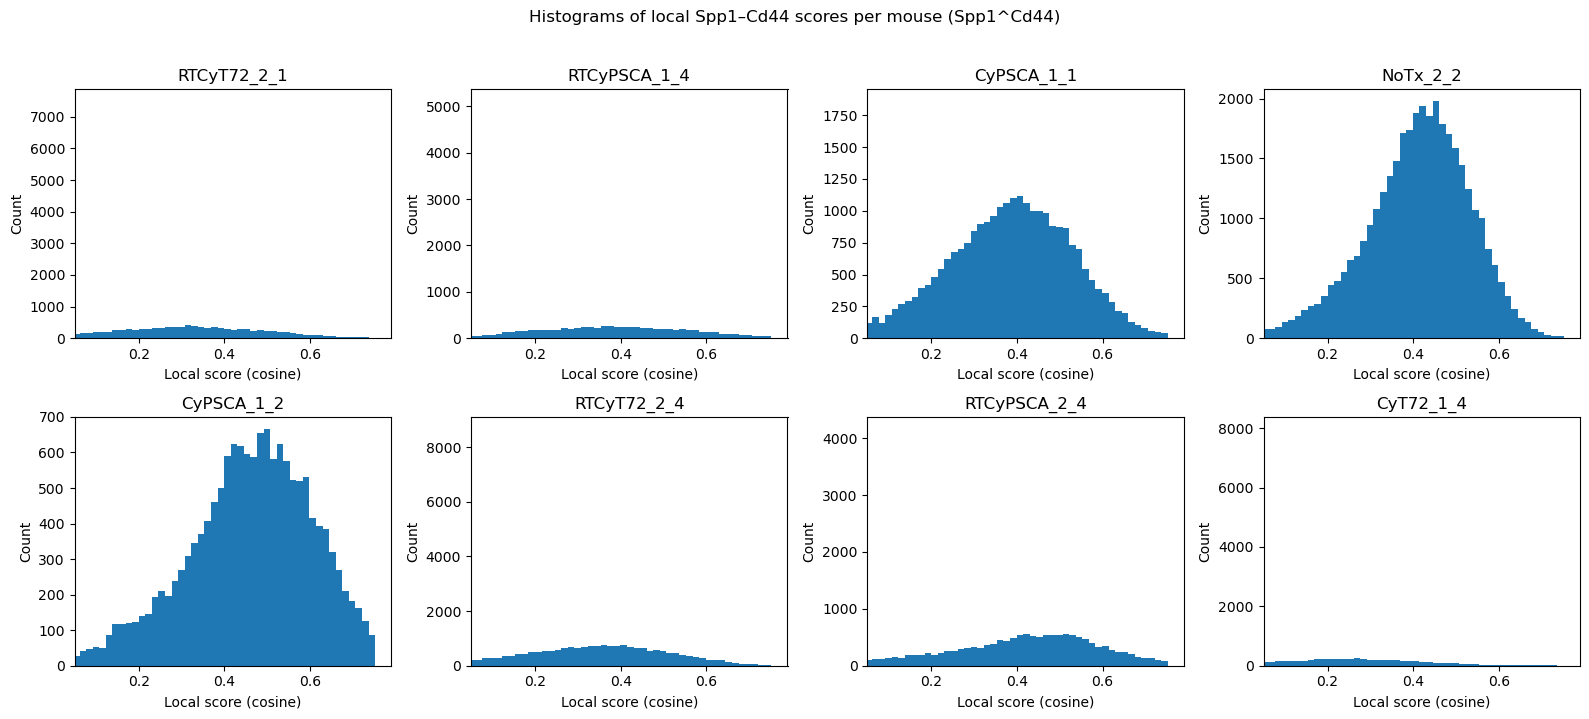

,mouse,n_cells,mean,median,p05,p95
2,CyPSCA_1_1,27254,0.361115,0.379330,0.000000,0.609597
4,CyPSCA_1_2,15179,0.458311,0.470632,0.171539,0.688427
7,CyT72_1_4,13636,0.120078,0.000000,0.000000,0.465914
3,NoTx_2_2,36255,0.403354,0.417923,0.155517,0.592695
1,RTCyPSCA_1_4,12667,0.235669,0.210452,0.000000,0.637028
6,RTCyPSCA_2_4,18697,0.332299,0.377103,0.000000,0.667664
0,RTCyT72_2_1,17578,0.194159,0.148713,0.000000,0.564938
5,RTCyT72_2_4,28507,0.247794,0.258200,0.000000,0.586003


In [79]:
import matplotlib.pyplot as plt
from scipy import sparse

# pull the column vector of local scores
xcol = lr_all.X[:, j].toarray().ravel() if sparse.issparse(lr_all.X) else np.asarray(lr_all.X[:, j]).ravel()

# prepare consistent bins across mice
finite_vals = xcol[np.isfinite(xcol)]
if finite_vals.size == 0:
    raise ValueError("All local scores are NaN/inf for this interaction.")
xmin, xmax = np.nanpercentile(finite_vals, [0.5, 99.5])  # robust range
if xmin == xmax:  # degenerate case
    xmin -= 1e-6; xmax += 1e-6
bins = np.linspace(xmin, xmax, 50)

mice = lr_all.obs['mouse'].astype(str).unique().tolist()
n = len(mice)
ncols = min(4, n)
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(4*ncols, 3.5*nrows))
stats_rows = []

for idx, m in enumerate(mice, 1):
    sel = (lr_all.obs['mouse'].astype(str).values == m)
    vals = xcol[sel]
    vals = vals[np.isfinite(vals)]

    ax = plt.subplot(nrows, ncols, idx)
    ax.hist(vals, bins=bins)  # default style, consistent bins
    ax.set_xlim(left=0.05)       # <-- force x-axis to 0 and above
    ax.set_title(m)
    ax.set_xlabel("Local score (cosine)")
    ax.set_ylabel("Count")

    if vals.size:
        stats_rows.append({
            'mouse': m,
            'n_cells': int(vals.size),
            'mean': float(np.nanmean(vals)),
            'median': float(np.nanmedian(vals)),
            'p05': float(np.nanpercentile(vals, 5)),
            'p95': float(np.nanpercentile(vals, 95))
        })
    else:
        stats_rows.append({'mouse': m, 'n_cells': 0, 'mean': np.nan, 'median': np.nan, 'p05': np.nan, 'p95': np.nan})

plt.suptitle(f"Histograms of local Spp1–Cd44 scores per mouse ({i_name})", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# tabular summary
stats_df = pd.DataFrame(stats_rows).sort_values('mouse')
display(stats_df)


# Pseudobulk Analysis

## Sanity Checking

In [ ]:
import numpy as np
import pandas as pd

def summarize_groups(adata, by, min_cells_per_grp=1, prefix=""):
    """
    Summarize how many unique mice are available per stratum and
    how many have BOTH Spp1pos and Spp1neg macrophages.
    - by: list[str] columns in adata.obs to group by (e.g., ["condition"], ["condition","tumor_location"])
    - min_cells_per_grp: require at least this many mac cells in each Spp1 group to count as 'both'
    - prefix: write_prefix if your columns were prefixed earlier
    """
    # required columns
    mac_col   = f"{prefix}Mac_like_tiered"
    spp1_col  = f"{prefix}Spp1_pos"
    assert all(c in adata.obs.columns for c in (mac_col, spp1_col, "mouse")), "Missing required columns"

    obs = adata.obs[[*by, "mouse", mac_col, spp1_col]].copy()
    obs = obs[obs[mac_col].astype(bool)]  # macrophages only
    obs["grp"] = np.where(obs[spp1_col].astype(int) == 1, "Spp1pos", "Spp1neg")

    # counts of mac cells per (stratum × mouse × grp)
    t = (
        obs.groupby(by + ["mouse", "grp"])
           .size()
           .unstack("grp", fill_value=0)
           .reset_index()
    )
    if "Spp1pos" not in t.columns: t["Spp1pos"] = 0
    if "Spp1neg" not in t.columns: t["Spp1neg"] = 0

    # per-mouse eligibility within each stratum
    t["has_both"] = (t["Spp1pos"] >= min_cells_per_grp) & (t["Spp1neg"] >= min_cells_per_grp)

    # summarize per stratum
    summary = (
        t.groupby(by)
         .agg(
             n_mice_total = ("mouse", "nunique"),
             n_mice_with_both = ("has_both", "sum"),
             mac_cells_Spp1pos = ("Spp1pos", "sum"),
             mac_cells_Spp1neg = ("Spp1neg", "sum"),
         )
         .reset_index()
         .sort_values("n_mice_with_both", ascending=False)
    )
    return summary, t  # summary per stratum; t has per-mouse cell counts

# ---- examples ----
# 1) By condition
summary_condition, per_mouse_condition = summarize_groups(adata, by=["condition"], min_cells_per_grp=10)

# 2) By tumor location
summary_location, per_mouse_location = summarize_groups(adata, by=["tumor_loc"], min_cells_per_grp=10)

# 3) By condition × tumor location
summary_cond_loc, per_mouse_cond_loc = summarize_groups(adata, by=["condition","tumor_loc"], min_cells_per_grp=10)

In [42]:
# quick views
print("per condition")
print(summary_condition.head(10))
print("per location")
print(summary_location.head(10))
print("per both")
print(summary_cond_loc.head(10))

per condition
  condition  n_mice_total  n_mice_with_both  mac_cells_Spp1pos  \
0    CyPSCA             8                 2               8253   
3  RTCyPSCA             8                 2               4412   
4   RTCyT72             8                 2               2065   
1     CyT72             8                 1                340   
2      NoTx             8                 1                483   

   mac_cells_Spp1neg  
0               1872  
3               1719  
4                678  
1                321  
2                 33  
per location
   tumor_loc  n_mice_total  n_mice_with_both  mac_cells_Spp1pos  \
0          1             8                 4               9924   
1          2             8                 4               5629   

   mac_cells_Spp1neg  
0               3061  
1               1562  
per both
  condition  tumor_loc  n_mice_total  n_mice_with_both  mac_cells_Spp1pos  \
0    CyPSCA          1             8                 2               8253   
9   

In [37]:
adata.obs.columns

Index(['id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'mouse', 'sample_id', 'condition', 'cx',
       'cy', 'TMA', 'library_id', 'n_counts', '_scvi_batch', '_scvi_labels',
       'cluster_cellcharter', 'M1_core_n', 'M1_acc_n', 'M2_core_n', 'M2_acc_n',
       'M1_total', 'M2_total', 'M1_score_tiered', 'M2_score_tiered',
       'Mac_polarization_tiered', 'Mac_like_tiered', 'Spp1_pos', 'Glp1r_pos',
       'Mac_Spp1_pos', 'Mac_Glp1r_pos', 'Mac_marker_combo'],
      dtype='object')

## Checking counts type

In [46]:
import numpy as np
import scipy.sparse as sp

def looks_like_counts(X, check_rows=1000, check_nnz=200_000):
    """
    Heuristic: returns True if X looks like integer count data.
    Works for dense ndarrays and SciPy sparse matrices without densifying the whole matrix.
    """
    if sp.issparse(X):
        # 1) dtype integer? then it's counts.
        if np.issubdtype(X.dtype, np.integer):
            # also check it’s not trivially tiny everywhere
            return X.max() > 10

        # 2) otherwise, sample up to check_nnz nonzero entries and test integer-ness
        data = X.data
        if data.size == 0:
            return False
        sample = data if data.size <= check_nnz else data[:check_nnz]
        int_like = np.all(np.isclose(sample, np.rint(sample)))
        return bool(int_like and sample.max() > 10)

    # Dense path
    arr = np.asarray(X)
    r = min(arr.shape[0], check_rows)
    sub = arr[:r]
    int_like = np.all(np.isclose(sub, np.rint(sub)))
    return bool(int_like and sub.max() > 10)

# Usage
use_counts_layer = ("counts" in adata.layers) and looks_like_counts(adata.layers["counts"])
if not use_counts_layer:
    print("WARNING: counts layer missing or not integer-like; proceeding from log/CPM (Path B).")


## Pseudo bulking 

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

group_key = "mouse"  # change to "sample" if that's your replicate ID
assert group_key in adata.obs.columns

mac_mask   = adata.obs["Mac_like_tiered"].astype(bool).values
spp1_mask  = adata.obs["Spp1_pos"].astype(int).values == 1
grp = np.where(spp1_mask, "Spp1pos", "Spp1neg")

# Counts matrix to aggregate
Xc = adata.layers["counts"]

# keep only macrophages
keep = mac_mask
Xk   = Xc[keep]
obsk = adata.obs.loc[keep, [group_key]].copy()
obsk["grp"] = grp[keep]

# keys: "<mouse>|<grp>"
keys = obsk[group_key].astype(str) + "|" + obsk["grp"].astype(str)
uniq = keys.unique()

rows, meta = [], []

for k in uniq:
    sel = (keys == k).values
    Xi  = Xk[sel]

    # sum to a 1 × G row (as ndarray)
    if sp.issparse(Xi):
        vec = Xi.sum(axis=0)                 # 1×G (numpy.matrix-like)
        vec = np.asarray(vec).ravel()        # (G,)
    else:
        vec = np.asarray(Xi.sum(axis=0)).ravel()  # (G,)

    rows.append(vec[np.newaxis, :])          # ensure 2-D (1, G)

    mouse_id, grp_name = k.split("|", 1)
    meta.append((k, mouse_id, grp_name))

# stack
Pb = np.vstack(rows)                         # dense is fine for DESeq2
pb_counts = pd.DataFrame(
    Pb.astype(int),                          # DESeq2 expects integer counts
    index=[m[0] for m in meta],
    columns=adata.var_names
)

# sanity checks
assert pb_counts.shape[0] == len(meta)
assert pb_counts.shape[1] == adata.n_vars
assert (pb_counts.values >= 0).all()
# Metadata for DE
coldata = pd.DataFrame({
    "key":     [m[0] for m in meta],
    "mouse":   [m[1] for m in meta],
    "group":   [m[2] for m in meta],  # Spp1pos / Spp1neg
}).set_index("key")

# keep only mice with BOTH groups (paired design)
have_both = (
    coldata.groupby("mouse")["group"]
    .apply(lambda s: set(s)=={"Spp1pos","Spp1neg"})
)
paired_mice = have_both[have_both].index.tolist()
sel = coldata["mouse"].isin(paired_mice)
pb_counts = pb_counts.loc[sel]
coldata   = coldata.loc[sel]

# Optional: filter low-count genes (keeps genes with ≥10 total counts across all pseudobulks)
keep_genes = (pb_counts.sum(axis=0) >= 10)
pb_counts  = pb_counts.loc[:, keep_genes]


from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Ensure row order matches between counts and metadata
assert (pb_counts.index == coldata.index).all()

# Categorical dtypes with correct reference level
coldata["mouse"] = coldata["mouse"].astype("category")
coldata["group"] = pd.Categorical(coldata["group"], categories=["Spp1neg","Spp1pos"])  # Spp1neg = reference

# Build and run DESeq2
dds = DeseqDataSet(
    counts=pb_counts.astype(int),      # integer counts
    metadata=coldata,                  # <-- was 'clinical'
    design_factors=["mouse","group"],
    refit_cooks=True
)
dds.deseq2()

# Wald test on the group effect (Spp1pos vs Spp1neg)
stat_res = DeseqStats(dds, contrast=["group","Spp1pos","Spp1neg"])
stat_res.summary()
res = stat_res.results_df.sort_values("padj", ascending=True)
res = res.rename(columns={"log2FoldChange": "log2FC"})

# quick sanity
print(res.head(10))
out_loc = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/")
out_file = out_loc / "DE_Spp1pos_vs_Spp1neg_pseudobulk_by_mouse.csv"
res.to_csv(out_file)


# Testing

In [39]:
adata.obs['tumor_loc'].unique()

<IntegerArray>
[2, 1]
Length: 2, dtype: Int64

In [22]:
adata.obs.columns

Index(['id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'mouse', 'sample_id', 'condition', 'cx',
       'cy', 'TMA', 'library_id', 'n_counts', '_scvi_batch', '_scvi_labels',
       'cluster_cellcharter', 'M1_core_n', 'M1_acc_n', 'M2_core_n', 'M2_acc_n',
       'M1_total', 'M2_total', 'M1_score_tiered', 'M2_score_tiered',
       'Mac_polarization_tiered', 'Mac_like_tiered', 'Spp1_pos', 'Glp1r_pos',
       'Mac_Spp1_pos', 'Mac_Glp1r_pos', 'Mac_marker_combo'],
      dtype='object')

In [35]:
adata.obs['mouse'].str.split('_', n=2).str[1].astype('Int64')

ID_100000    2
ID_100001    2
ID_100005    2
ID_100006    2
ID_100007    2
            ..
ID_246544    2
ID_246548    2
ID_246563    2
ID_246577    2
ID_246579    2
Name: mouse, Length: 169773, dtype: Int64